# Tuner para treinamento do Modelo Preditivo de RUL

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import keras_tuner as kt
import shap

I0000 00:00:1789427733.940042  114301 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789427734.183800  114301 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
E0000 00:00:1789427736.719383  114301 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1789427736.719841  114301 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1789427736.719849  114301 instrument.cc:563] Metric 

## 1. Carregando os Dados
Carregamos as variáveis de voo (`W`), sensores físicos (`X_s`), o RUL (`Y`) e a unidade de voo (`A`).

In [2]:
filename = 'data/N-CMAPSS_DS02-006.h5'

with h5py.File(filename, 'r') as hdf:
    W_dev = np.array(hdf.get('W_dev'))
    X_s_dev = np.array(hdf.get('X_s_dev'))
    Y_dev = np.array(hdf.get('Y_dev'))
    A_dev = np.array(hdf.get('A_dev'))  # Unidade (A_dev[:,0]) para o groupby
    
    W_test = np.array(hdf.get('W_test'))
    X_s_test = np.array(hdf.get('X_s_test'))
    Y_test = np.array(hdf.get('Y_test'))
    A_test = np.array(hdf.get('A_test'))

## 2. Pré-processamento e Engenharia de Features 

In [3]:
# Função para criar DataFrame e adicionar Sliding Windows
def create_temporal_features(W, X_s, Y, A, window=20):
    # Juntando tudo num dataframe temporário
    df = pd.DataFrame(np.concatenate((W, X_s), axis=1))
    df['unit'] = A[:, 0]
    df['RUL'] = Y.flatten()
    
    print("Calculando médias e variâncias móveis")
    # Média Móvel
    df_mean = df.groupby('unit').rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True).sort_index()
    # Variância Móvel
    df_var = df.groupby('unit').rolling(window=window, min_periods=1).var().fillna(0).reset_index(level=0, drop=True).sort_index()
    
    # Renomeando as colunas
    cols = [f'feat_{i}' for i in range(W.shape[1] + X_s.shape[1])]
    df_mean = df_mean[df.columns[:-2]]
    df_var = df_var[df.columns[:-2]]
    
    df_mean.columns = [c + '_mean' for c in cols]
    df_var.columns = [c + '_var' for c in cols]
    
    df_raw = pd.DataFrame(np.concatenate((W, X_s), axis=1), columns=cols)
    
    # Features brutas + média móvel + variância móvel
    X_temporal = pd.concat([df_raw, df_mean, df_var], axis=1).values
    return X_temporal, df['RUL'].values

In [4]:
# Train_Test_Split
X_train_raw, y_train_full = create_temporal_features(W_dev, X_s_dev, Y_dev, A_dev, window=20)
X_test_raw, y_test = create_temporal_features(W_test, X_s_test, Y_test, A_test, window=20)

# Escalonamento
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Criando um AMOSTRA para o KerasTuner rodar rápido (5% dos dados)
amostra = int(len(X_train_scaled_full) * 0.05)
X_train_scaled_sample = X_train_scaled_full[:amostra]
y_train_sample = y_train_full[:amostra]

print(f"Shape do Treino Completo (Final): {X_train_scaled_full.shape}")
print(f"Shape do Treino Amostrado (Tuner): {X_train_scaled_sample.shape}")

Calculando médias e variâncias móveis
Calculando médias e variâncias móveis
Shape do Treino Completo (Final): (5263447, 54)
Shape do Treino Amostrado (Tuner): (263172, 54)


## 3. Tuner e Construção da Arquitetura Deep MLP

In [5]:
def build_model(hp):
    model = Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train_scaled_sample.shape[1],)))
    
    hp_units = hp.Int('units_1', min_value=64, max_value=256, step=64)
    hp_dropout = hp.Choice('dropout', values=[0.1, 0.2])
    
    # Camada 1
    model.add(Dense(units=hp_units, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(hp_dropout))
    
    # Camada 2
    model.add(Dense(units=hp_units // 2, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(hp_dropout))
    
    # Camada 3
    model.add(Dense(units=hp_units // 4, activation='relu'))
    model.add(BatchNormalization())
    
    # Saída
    model.add(Dense(1, activation='linear'))
    
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
                  loss='mse',
                  metrics=['mae'])
    return model

In [6]:
# Limpando o tuner antigo se necessário
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=20,
                     factor=3,
                     directory='meu_tuner',
                     project_name='rul_high_r2',
                     overwrite=False)

stop_early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Iniciando otimização temporal...")
tuner.search(X_train_scaled_sample, y_train_sample, epochs=50, validation_split=0.2, batch_size=4096, callbacks=[stop_early])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Melhor rede encontrou: {best_hps.values}")

Reloading Tuner from meu_tuner/rul_high_r2/tuner0.json
Iniciando otimização temporal...
Melhor rede encontrou: {'units_1': 128, 'dropout': 0.1, 'learning_rate': 0.01, 'tuner/epochs': 3, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}


## 4. Avaliação Final

In [ ]:
final_model = tuner.hypermodel.build(best_hps)

history = final_model.fit(
    X_train_scaled_full, y_train_full,
    validation_split=0.2, 
    epochs=50, 
    batch_size=4096, 
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=2
)

I0000 00:00:1789427750.119492  114301 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5743 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


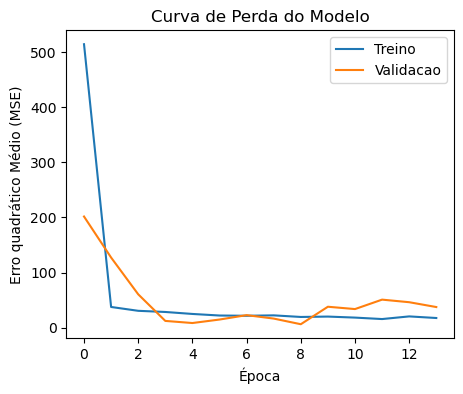

In [ ]:
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
#plt.yscale("log")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])
plt.show()

In [ ]:
y_pred = final_model.predict(X_test_scaled)

39180/39180 ━━━━━━━━━━━━━━━━━━━━ 56s 1ms/step


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE no Teste: {mae:.2f}")
print(f"RMSE no Teste: {rmse:.2f}")
print(f"R² Score (Meta > 0.99): {r2:.4f}")

MAE no Teste: 8.80
RMSE no Teste: 12.30
R² Score (Meta > 0.99): 0.5797


In [ ]:
final_model.save('model/model_tuner.keras')